<div style="background:#262766;color:white;padding:10px;text-align:center;font-size:26px">
Prévision avec SARIMA
</div>

In [197]:
# ==========================
# Importation des bibliothèques
# ==========================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from itertools import product
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings

warnings.filterwarnings("ignore")

In [198]:
# ==========================
# Chargement du fichier
# ==========================

df = pd.read_csv(
    "export/meteo_france_clean.csv"
)

df["MOIS_ANNEE"] = pd.to_datetime(df["MOIS_ANNEE"])
df["MOIS_ANNEE"] = df["MOIS_ANNEE"].dt.to_period("M")

In [199]:
# ==========================
# Taille du jeu de données
# ==========================
print(f"Nombre de lignes : {df.shape[0]:,}".replace(",", " "))
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 133 847
Nombre de colonnes : 23


In [200]:
print(df.columns.tolist())

['ID_STATION', 'NOM_STATION', 'LATITUDE', 'LONGITUDE', 'ALTITUDE_M', 'ANNEE_MOIS', 'PRECIPITATIONS_MM', 'PRECIP_MAX_24H_MM', 'TEMP_MAX_MOY_C', 'TEMP_MAX_ABS_C', 'TEMP_MAX_MIN_C', 'TEMP_MIN_MOY_C', 'TEMP_MIN_ABS_C', 'TEMP_MIN_MAX_C', 'AMPLITUDE_THERMIQUE_MOY_C', 'AMPLITUDE_THERMIQUE_MAX_C', 'TEMP_MOYENNE_C', 'TEMP_MOYENNE_QUOTIDIENNE_C', 'TEMP_MOY_MIN_C', 'TEMP_MOY_MAX_C', 'EVAPOTRANSPIRATION_MM', 'CODE_DEPARTEMENT', 'MOIS_ANNEE']


In [201]:
# ==========================
# Affichage du dataframe
# ==========================
df.head()

,ID_STATION,NOM_STATION,LATITUDE,LONGITUDE,ALTITUDE_M,ANNEE_MOIS,PRECIPITATIONS_MM,PRECIP_MAX_24H_MM,TEMP_MAX_MOY_C,TEMP_MAX_ABS_C,...,TEMP_MIN_MAX_C,AMPLITUDE_THERMIQUE_MOY_C,AMPLITUDE_THERMIQUE_MAX_C,TEMP_MOYENNE_C,TEMP_MOYENNE_QUOTIDIENNE_C,TEMP_MOY_MIN_C,TEMP_MOY_MAX_C,EVAPOTRANSPIRATION_MM,CODE_DEPARTEMENT,MOIS_ANNEE
0,1014002,ARBENT,46.278167,5.669,534,202501,187.3,46.0,8.6,18.4,...,9.3,10.6,22.6,3.3,2.8,-4.9,13.9,24.0,1,2025-01
1,1014002,ARBENT,46.278167,5.669,534,202502,54.0,23.0,10.0,17.5,...,9.0,10.5,21.1,4.7,3.8,-1.7,13.3,25.5,1,2025-02
2,1014002,ARBENT,46.278167,5.669,534,202503,64.2,15.6,14.1,21.1,...,10.3,14.4,23.6,6.9,6.2,1.7,15.7,54.7,1,2025-03
3,1014002,ARBENT,46.278167,5.669,534,202504,126.0,37.4,18.9,25.7,...,11.1,16.0,24.9,10.9,10.5,5.4,15.7,82.7,1,2025-04
4,1014002,ARBENT,46.278167,5.669,534,202505,133.7,46.8,20.8,31.3,...,12.5,14.5,23.5,13.6,13.3,5.0,20.6,103.2,1,2025-05


### Première approche de prévision avec un modèle SARIMA

Afin d'évaluer la faisabilité d'une prévision des températures, un premier modèle de série temporelle est construit à l'échelle d'une **station météorologique**.

La série est découpée en deux parties :
- **jeu d'entraînement** : de janvier 2021 à juin 2025 (54 mois) ;
- **jeu de test** : de juillet 2025 à juin 2026 (12 mois).

Cette séparation chronologique permet d'entraîner le modèle sur les données historiques puis d'évaluer sa capacité à prédire une période qu'il n'a jamais observée.

Le modèle retenu est un **SARIMA (Seasonal AutoRegressive Integrated Moving Average)**, particulièrement adapté aux séries temporelles mensuelles présentant une saisonnalité annuelle. Les paramètres utilisés pour cette première expérimentation sont :

- **ARIMA** : (1,1,1)
- **Saisonnier** : (1,1,1,12)

L'objectif de cette première étape n'est pas d'obtenir le modèle optimal, mais de vérifier qu'un modèle simple est capable de reproduire correctement la dynamique des températures.

In [202]:
# ==========================
# Test sur une station
# ==========================

# On regarde les stations avec le plus d'observations
# On choisit une station

nb_obs = (
    df.groupby("ID_STATION")
      .size()
      .sort_values(ascending=False)
)

nb_obs.head()

station = nb_obs.index[0]

station

np.int64(1014002)

In [203]:
# Affichage des données de la station

df_station = (
    df[df["ID_STATION"] == station]
    .sort_values("MOIS_ANNEE")
)

print(df_station.shape)

df_station.head()

(66, 23)


,ID_STATION,NOM_STATION,LATITUDE,LONGITUDE,ALTITUDE_M,ANNEE_MOIS,PRECIPITATIONS_MM,PRECIP_MAX_24H_MM,TEMP_MAX_MOY_C,TEMP_MAX_ABS_C,...,TEMP_MIN_MAX_C,AMPLITUDE_THERMIQUE_MOY_C,AMPLITUDE_THERMIQUE_MAX_C,TEMP_MOYENNE_C,TEMP_MOYENNE_QUOTIDIENNE_C,TEMP_MOY_MIN_C,TEMP_MOY_MAX_C,EVAPOTRANSPIRATION_MM,CODE_DEPARTEMENT,MOIS_ANNEE
287,1014002,ARBENT,46.278167,5.669,534,202101,242.6,35.0,4.0,11.2,...,7.8,6.4,19.4,0.7,0.8,-6.9,9.5,14.5,1,2021-01
288,1014002,ARBENT,46.278167,5.669,534,202102,65.0,20.0,11.8,22.1,...,8.5,11.1,23.3,6.3,5.8,-4.5,13.1,34.7,1,2021-02
289,1014002,ARBENT,46.278167,5.669,534,202103,94.0,18.2,13.2,25.1,...,4.4,15.5,26.3,5.4,4.8,0.2,13.1,56.4,1,2021-03
290,1014002,ARBENT,46.278167,5.669,534,202104,55.6,23.0,15.9,25.2,...,8.7,17.2,24.7,7.3,7.2,1.2,15.2,80.4,1,2021-04
291,1014002,ARBENT,46.278167,5.669,534,202105,263.9,70.0,17.3,25.8,...,15.3,12.5,23.4,11.0,10.9,6.3,20.6,91.2,1,2021-05


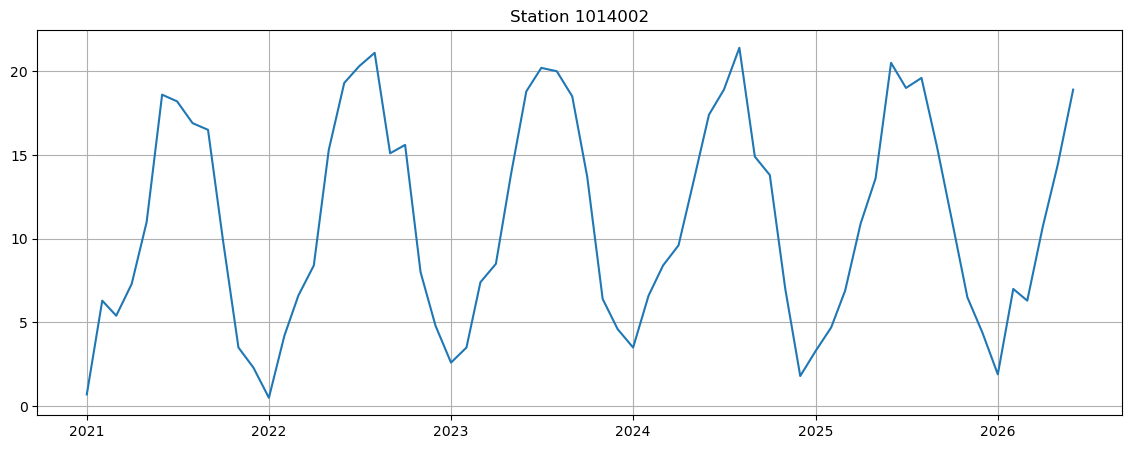

In [204]:
# Vérification graphique de la série
plt.figure(figsize=(14,5))

plt.plot(
    df_station["MOIS_ANNEE"].dt.to_timestamp(),
    df_station["TEMP_MOYENNE_C"]
)

plt.title(f"Station {station}")
plt.grid()

plt.show()

In [205]:
# ==========================
# #Création de la série temporelle
# ==========================

serie = (
    df_station
    .set_index("MOIS_ANNEE")["TEMP_MOYENNE_C"]
)

serie.index = serie.index.to_timestamp()

serie.head()

MOIS_ANNEE
2021-01-01     0.7
2021-02-01     6.3
2021-03-01     5.4
2021-04-01     7.3
2021-05-01    11.0
Freq: MS, Name: TEMP_MOYENNE_C, dtype: float64

In [206]:
# Vérification des valeurs manquantes
print(serie.isna().sum())

0


In [207]:
# ==========================
# Séparation train / test
# ==========================

train = serie[serie.index < "2025-07-01"]
test = serie[serie.index >= "2025-07-01"]

print(len(train))
print(len(test))

54
12


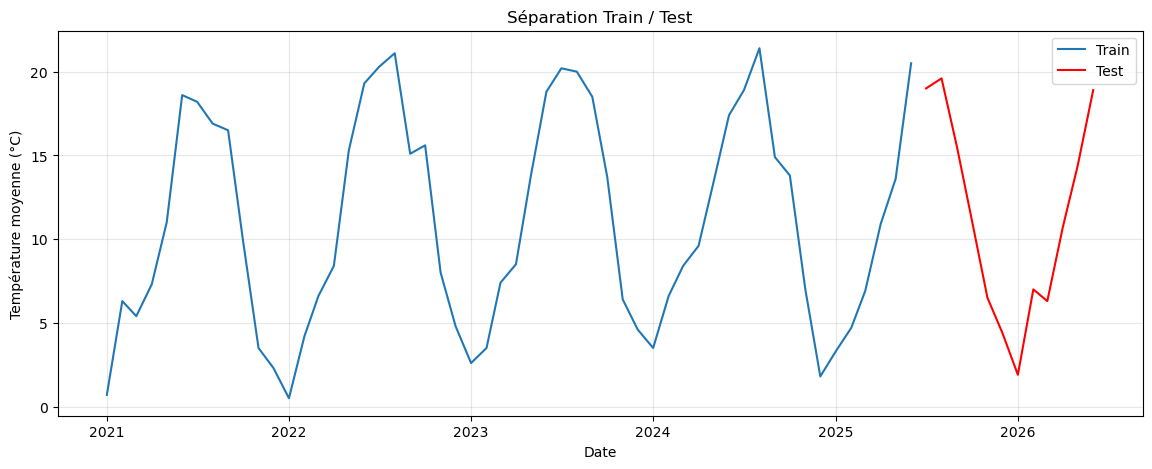

In [208]:
# Vérification visuelle de la séparation
plt.figure(figsize=(14, 5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="red")

plt.title("Séparation Train / Test")
plt.xlabel("Date")
plt.ylabel("Température moyenne (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [209]:
# ==========================
# Entraînement du modèle SARIMA
# ==========================

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     TEMP_MOYENNE_C   No. Observations:                   54
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -45.040
Date:                            Tue, 30 Jun 2026   AIC                            100.079
Time:                                    17:36:14   BIC                            106.558
Sample:                                01-01-2021   HQIC                           102.006
                                     - 06-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1800      0.407     -0.442      0.658      -0.978       0.618
ma.L1         -0.3880      0.397   

In [210]:
# ==========================
# Prédictions sur le jeu de test
# ==========================

pred = results.get_forecast(steps=len(test))

pred_mean = pred.predicted_mean

conf_int = pred.conf_int()

In [211]:
# ==========================
# Evaluation
# ==========================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))

print(f"MAE  : {mae:.2f} °C")
print(f"RMSE : {rmse:.2f} °C")

MAE  : 1.68 °C
RMSE : 2.07 °C


<div style="background-color: rgba(0, 200, 0, 0.1); padding: 10px; border-radius: 8px;">

#### Premiers résultats

Les résultats obtenus sont encourageants :
- la saisonnalité annuelle est correctement reproduite ;
- les pics estivaux et les minima hivernaux sont bien anticipés ;
- les observations restent majoritairement comprises dans l'intervalle de confiance des prévisions.

Les indicateurs d'évaluation confirment cette bonne qualité de prédiction :

- **MAE (Mean Absolute Error)** : **1,68 °C**
- **RMSE (Root Mean Squared Error)** : **2,07 °C**

Ces erreurs restent limitées au regard de l'amplitude annuelle des températures observées, ce qui montre qu'un modèle SARIMA constitue une base pertinente pour la prévision des températures mensuelles. Dans la suite de l'étude, les paramètres du modèle pourront être optimisés afin d'améliorer encore les performances avant de généraliser l'approche à l'ensemble des stations météorologiques.

</div>

In [212]:
# ==========================
# Recherche du meilleur modèle avec les paramètres
# ==========================

# ==========================
# Grille des paramètres
# ==========================

p = [0, 1, 2]
d = [1]
q = [0, 1, 2]

P = [0, 1]
D = [1]
Q = [0, 1]

s = 12

# ==========================
# Recherche des meilleurs paramètres
# ==========================

resultats = []

combinaisons = list(product(p, d, q, P, D, Q))

print(f"Nombre de modèles à tester : {len(combinaisons)}")

for i, (p_, d_, q_, P_, D_, Q_) in enumerate(combinaisons, start=1):

    order = (p_, d_, q_)
    seasonal_order = (P_, D_, Q_, s)

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        results = model.fit(disp=False)

        pred = results.get_forecast(steps=len(test))
        pred_mean = pred.predicted_mean

        mae = mean_absolute_error(test, pred_mean)
        rmse = np.sqrt(mean_squared_error(test, pred_mean))

        resultats.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": results.aic,
            "MAE": mae,
            "RMSE": rmse
        })

    except Exception:

        resultats.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan
        })

# ==========================
# Résultats
# ==========================

df_resultats = (
    pd.DataFrame(resultats)
      .dropna()
      .sort_values(["RMSE", "MAE"])
      .reset_index(drop=True)
)

print("\nMeilleur modèle :")
display(df_resultats.head(1))

Nombre de modèles à tester : 36

Meilleur modèle :


,order,seasonal_order,AIC,MAE,RMSE
0,"(1, 1, 2)","(0, 1, 0, 12)",172.06086,1.342888,1.560624


In [213]:
# ==========================
# Entraînement du modèle SARIMA
# ==========================

model = SARIMAX(
    train,
    order=(1, 1, 2),
    seasonal_order=(0, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

                                      SARIMAX Results                                      
Dep. Variable:                      TEMP_MOYENNE_C   No. Observations:                   54
Model:             SARIMAX(1, 1, 2)x(0, 1, [], 12)   Log Likelihood                 -82.030
Date:                             Tue, 30 Jun 2026   AIC                            172.061
Time:                                     17:36:18   BIC                            178.611
Sample:                                 01-01-2021   HQIC                           174.391
                                      - 06-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7500      0.179     -4.190      0.000      -1.101      -0.399
ma.L1          0.1159      

In [214]:
# ==========================
# Prédictions sur le jeu de test
# ==========================

pred = results.get_forecast(steps=len(test))

pred_mean = pred.predicted_mean

conf_int = pred.conf_int()

In [215]:
# ==========================
# Evaluation
# ==========================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))

print(f"MAE  : {mae:.2f} °C")
print(f"RMSE : {rmse:.2f} °C")

MAE  : 1.34 °C
RMSE : 1.56 °C


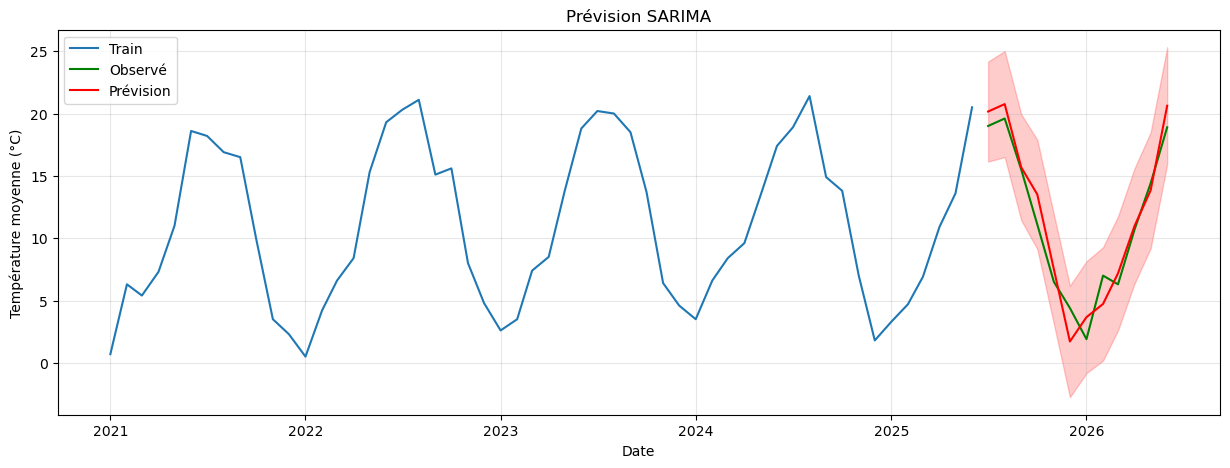

In [216]:
# ==========================
# Visualisation
# ==========================
plt.figure(figsize=(15,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Observé", color="green")

plt.plot(pred_mean.index,
         pred_mean,
         label="Prévision",
         color="red")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color="red",
    alpha=0.2
)

plt.title("Prévision SARIMA")
plt.xlabel("Date")
plt.ylabel("Température moyenne (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<div style="background-color: rgba(0, 200, 0, 0.1); padding: 10px; border-radius: 8px;">

### Optimisation des paramètres du modèle SARIMA

Le modèle SARIMA utilisé initialement `(1,1,1)(1,1,1,12)` constitue un premier choix classique pour des séries temporelles mensuelles présentant une saisonnalité annuelle.

Afin d'améliorer les performances, une **recherche par grille (grid search)** est réalisée sur plusieurs combinaisons de paramètres `(p,d,q)` et `(P,D,Q,12)`. Chaque modèle est entraîné sur le même jeu d'apprentissage puis évalué sur le jeu de test à l'aide des indicateurs **MAE** et **RMSE**.

Le modèle **SARIMA (1,1,2)(0,1,0,12)** obtient les meilleurs résultats avec un **MAE de 1,34 °C** et un **RMSE de 1,56 °C**. Il est donc retenu pour générer les prévisions sur l'ensemble des stations météorologiques.

</div>

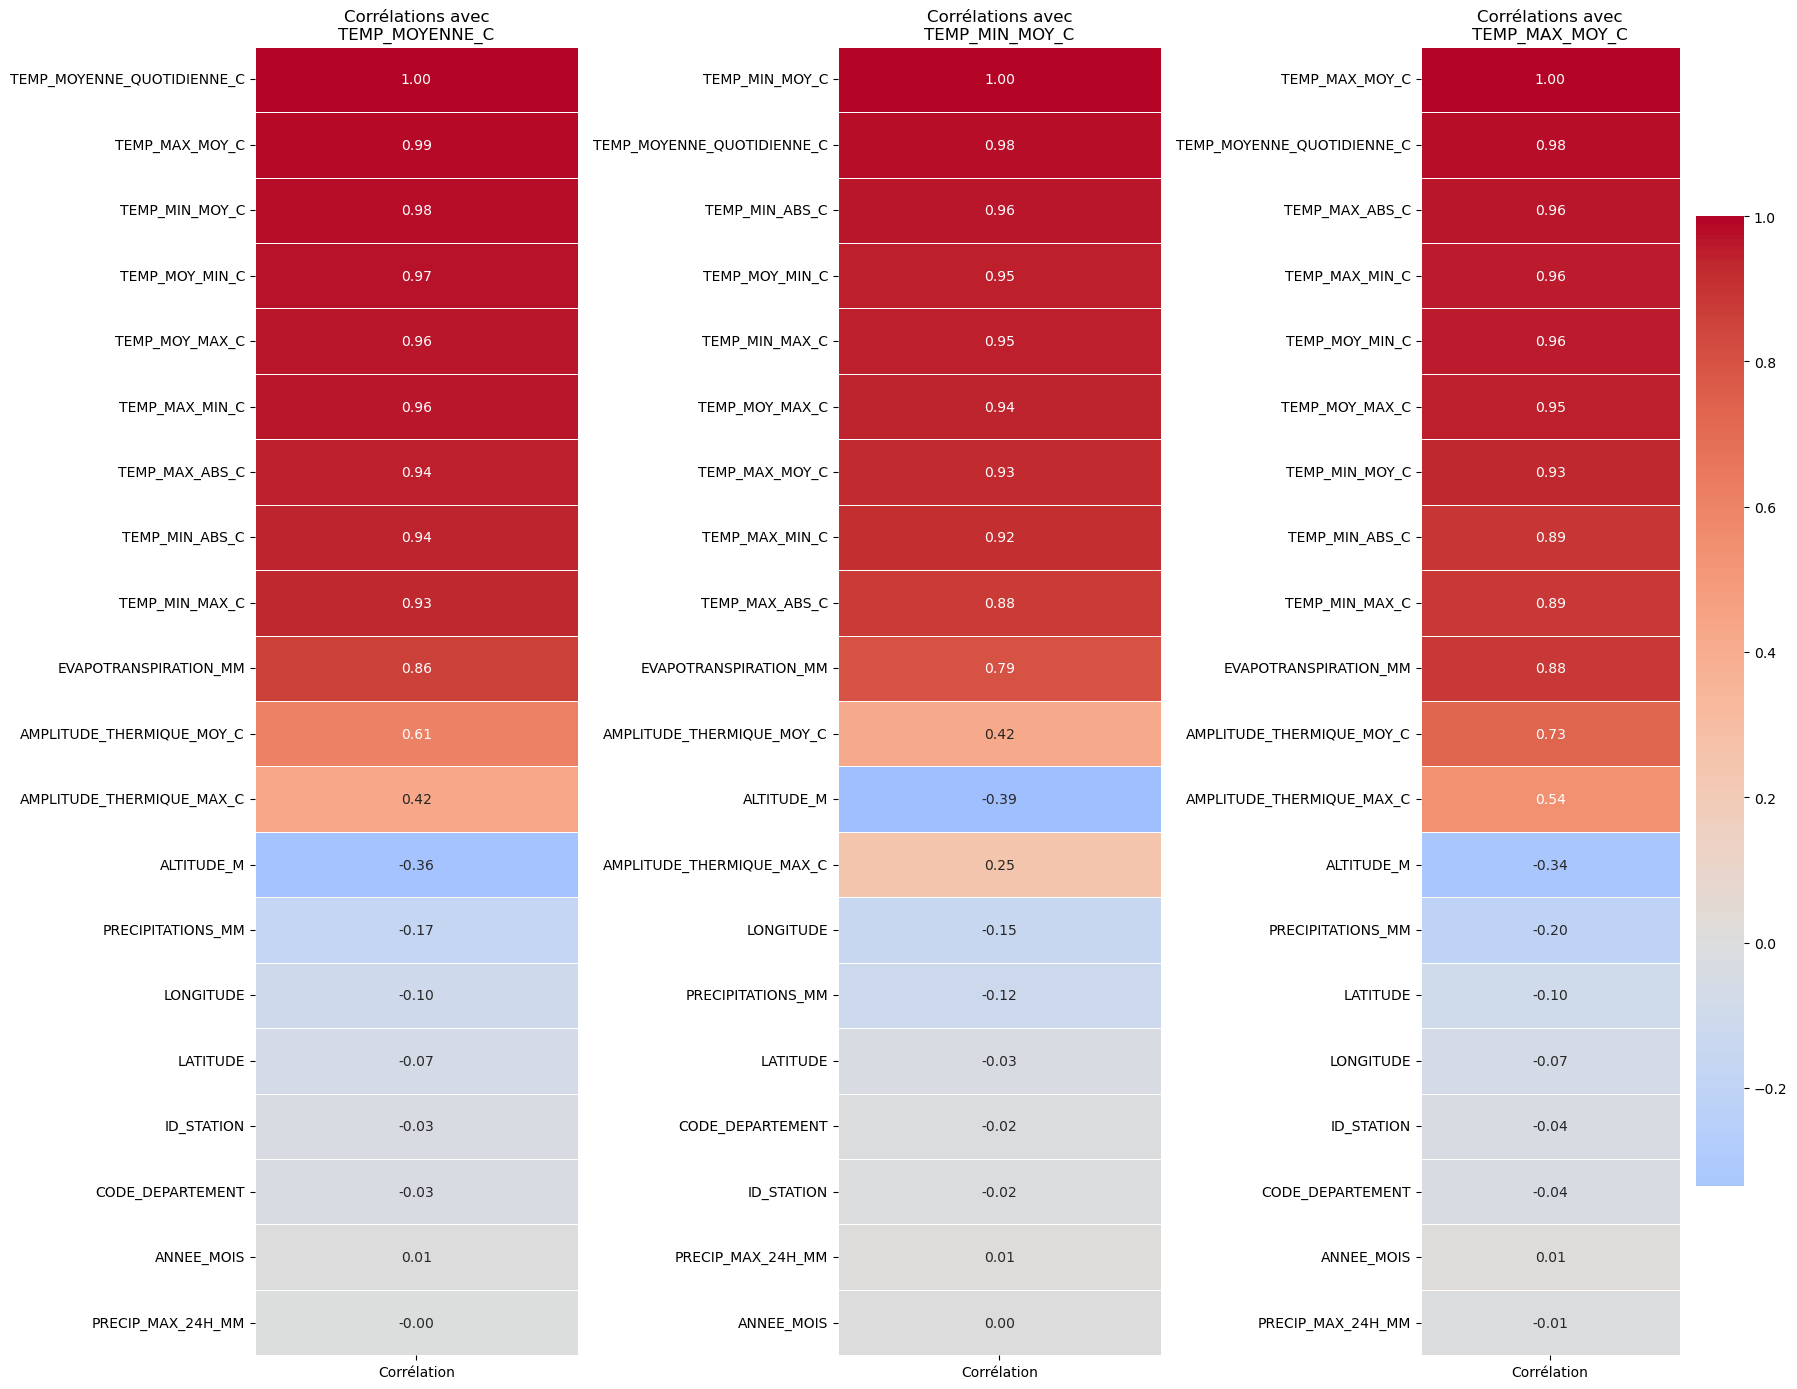

In [217]:
# ==========================
# Analyse des coorélations pour sélection des variables exogènes
# ==========================

variables_cibles = [
    "TEMP_MOYENNE_C",
    "TEMP_MIN_MOY_C",
    "TEMP_MAX_MOY_C"
]

# Variables numériques
df_num = df.select_dtypes(include="number")

fig, axes = plt.subplots(1, 3, figsize=(18, 14))

for ax, cible in zip(axes, variables_cibles):

    # On exclut les 3 variables cibles
    variables_a_exclure = [
        "TEMP_MOYENNE_C",
        "TEMP_MIN_C",
        "TEMP_MAX_C",
        "TX",
        "TN",
        "TM"
    ]

    correlations = (
        df_num.corr(numeric_only=True)[cible]
        .drop(labels=[v for v in variables_a_exclure if v in df_num.columns])
        .sort_values(key=abs, ascending=False)
    )

    sns.heatmap(
        correlations.to_frame(name="Corrélation"),
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        linewidths=0.5,
        ax=ax,
        cbar=(ax == axes[-1])  # Une seule barre de couleurs
    )

    ax.set_title(f"Corrélations avec\n{cible}")

plt.tight_layout()
plt.show()

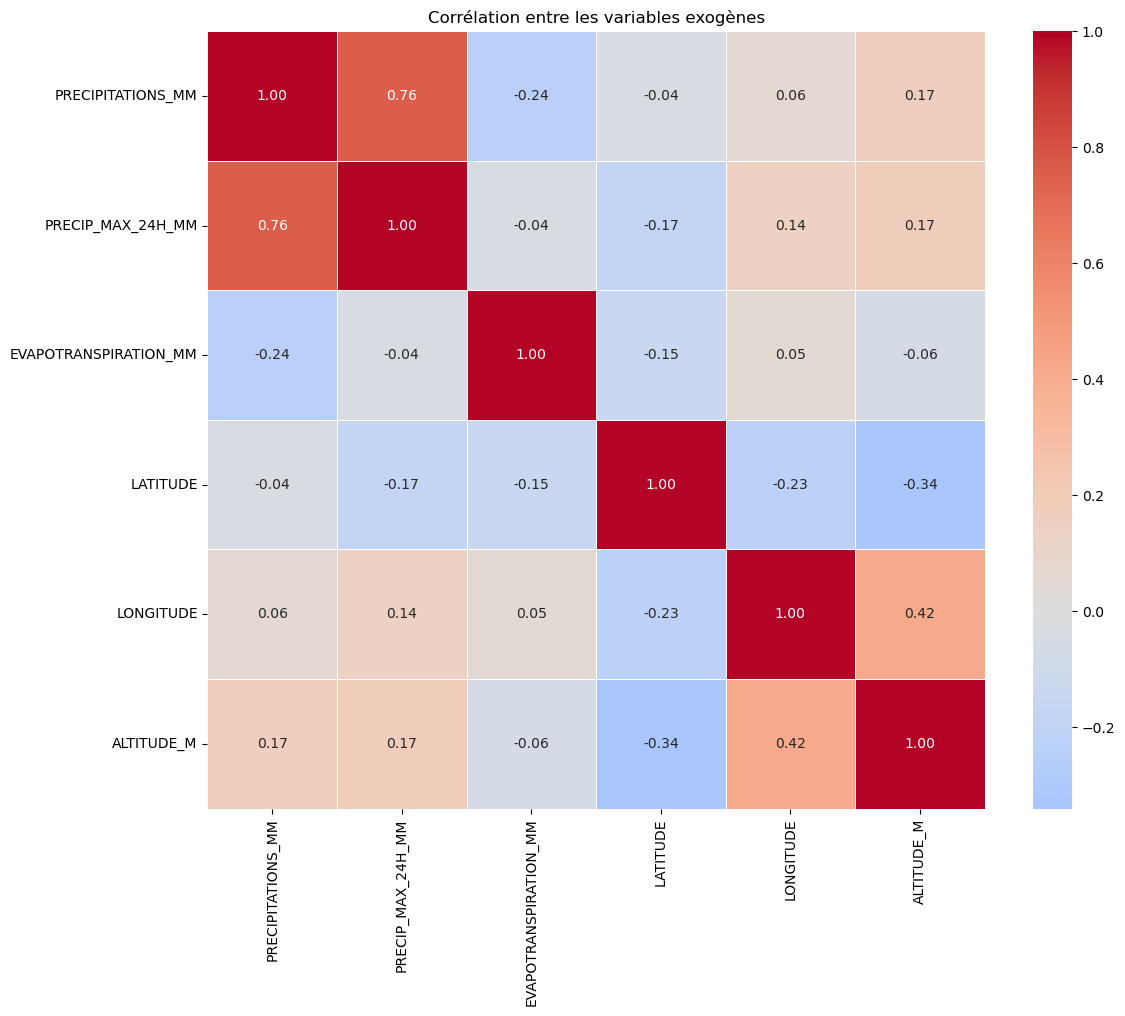

In [218]:
#-------------
# Variables cnadidates
#-------------
variables_exogenes = [
    "PRECIPITATIONS_MM",
    "PRECIP_MAX_24H_MM",
    "EVAPOTRANSPIRATION_MM",
    "LATITUDE",
    "LONGITUDE",
    "ALTITUDE_M"
]

corr = df[variables_exogenes].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Corrélation entre les variables exogènes")
plt.tight_layout()
plt.show()

<div style="background-color: rgba(0, 200, 0, 0.1); padding: 10px; border-radius: 8px;">

## Sélection des variables exogènes pour le modèle SARIMAX

Avant d'entraîner le modèle SARIMAX, nous avons analysé les corrélations afin de sélectionner les variables exogènes les plus pertinentes.

Dans un premier temps, une matrice de corrélation a été réalisée entre les variables de température cibles (`TEMP_MOYENNE_C`, `TEMP_MIN_MOY_C` et `TEMP_MAX_MOY_C`) et l'ensemble des autres variables du jeu de données. Cette analyse a montré que de nombreuses variables étaient fortement corrélées avec les températures, mais qu'il s'agissait principalement d'autres indicateurs de température ou de variables directement calculées à partir de celles-ci. Ces variables ont donc été écartées afin d'éviter les fuites d'information.

Nous avons ensuite étudié les corrélations entre les variables exogènes candidates (précipitations, évapotranspiration et caractéristiques géographiques). Cette seconde matrice a permis d'identifier plusieurs groupes de variables très corrélées entre elles, notamment les différents indicateurs de précipitations.

Afin de limiter la redondance et la multicolinéarité, une seule variable représentative a été retenue pour chaque groupe. Les coordonnées géographiques (`LATITUDE`, `LONGITUDE` et `ALTITUDE_M`) n'ont pas été conservées, car elles sont constantes pour une station donnée et n'apportent pas d'information temporelle au modèle.

Les variables exogènes retenues pour les premiers tests du modèle SARIMAX sont donc :

- `PRECIPITATIONS_MM`
- `PRECIP_MAX_24H_MM`
- `EVAPOTRANSPIRATION_MM`
</div>

## Entraînement du modèle SARIMAX

Après avoir évalué le modèle SARIMA, nous testons un modèle **SARIMAX**. Contrairement au SARIMA, le SARIMAX permet d'intégrer des **variables exogènes**, c'est-à-dire des variables explicatives susceptibles d'influencer la température, comme les précipitations ou l'évapotranspiration.

Dans un premier temps, nous conservons les mêmes paramètres `(p, d, q)` et `(P, D, Q, s)` que ceux sélectionnés pour le meilleur modèle SARIMA afin d'évaluer uniquement l'apport des variables exogènes. Si les résultats sont encourageants, une nouvelle recherche des paramètres optimaux pourra ensuite être réalisée spécifiquement pour le SARIMAX.

In [219]:
# ==========================
# Préparation SARIMAX avec variables exogènes
# ==========================

variable_cible = "TEMP_MOYENNE_C"

variables_exogenes = [
    "PRECIPITATIONS_MM",
    "EVAPOTRANSPIRATION_MM"
]

df_station = (
    df[df["ID_STATION"] == station]
    .sort_values("MOIS_ANNEE")
    .set_index("MOIS_ANNEE")
)

df_station.index = df_station.index.to_timestamp()
df_station = df_station.asfreq("MS")

cols_model = [variable_cible] + variables_exogenes

df_model = df_station[cols_model].interpolate(limit_direction="both")

train_df = df_model[df_model.index < "2025-07-01"]
test_df = df_model[df_model.index >= "2025-07-01"]

y_train = train_df[variable_cible]
y_test = test_df[variable_cible]

X_train = train_df[variables_exogenes]
X_test = test_df[variables_exogenes]

In [220]:
# ==========================
# Entraînement SARIMAX
# ==========================

model_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarimax = model_sarimax.fit(disp=False)

pred_sarimax = results_sarimax.get_forecast(
    steps=len(y_test),
    exog=X_test
)

pred_sarimax_mean = pred_sarimax.predicted_mean
conf_int_sarimax = pred_sarimax.conf_int()

In [221]:
# ==========================
# Évaluation SARIMAX
# ==========================

mae_sarimax = mean_absolute_error(y_test, pred_sarimax_mean)
rmse_sarimax = np.sqrt(mean_squared_error(y_test, pred_sarimax_mean))

print(f"MAE SARIMAX  : {mae_sarimax:.2f} °C")
print(f"RMSE SARIMAX : {rmse_sarimax:.2f} °C")

MAE SARIMAX  : 1.16 °C
RMSE SARIMAX : 1.34 °C


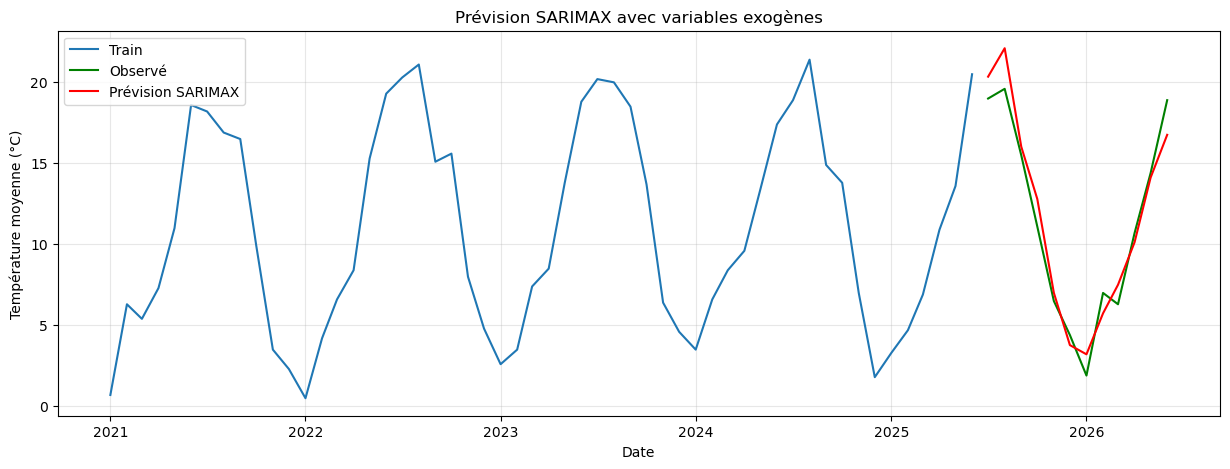

In [222]:
# ==========================
# Visualisation SARIMAX
# ==========================
plt.figure(figsize=(15, 5))

plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Observé", color="green")
plt.plot(pred_sarimax_mean.index, pred_sarimax_mean, label="Prévision SARIMAX", color="red")

plt.title("Prévision SARIMAX avec variables exogènes")
plt.xlabel("Date")
plt.ylabel("Température moyenne (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<div style="background-color: rgba(0, 200, 0, 0.1); padding: 10px; border-radius: 8px;">

## Évaluation et sélection du modèle SARIMAX

Plusieurs configurations du modèle SARIMAX ont été testées afin d'évaluer l'apport des variables exogènes et l'influence des paramètres du modèle.

Deux ensembles de variables explicatives ont été comparés :

- `PRECIPITATIONS_MM` et `EVAPOTRANSPIRATION_MM`
- `PRECIPITATIONS_MM`, `PRECIP_MAX_24H_MM` et `EVAPOTRANSPIRATION_MM`

Pour chacun, deux jeux de paramètres ont été évalués :
- les paramètres standards `(1,1,1)(1,1,1,12)` ;
- les paramètres optimisés par recherche de l'AIC.

Les résultats montrent que :

- le modèle utilisant uniquement **les précipitations et l'évapotranspiration** obtient les meilleures performances ;
- l'ajout de `PRECIP_MAX_24H_MM` n'améliore pas les prédictions et dégrade même les résultats ;
- les paramètres sélectionnés par l'AIC ne conduisent pas aux meilleures performances sur le jeu de test.

Le modèle retenu est donc le **SARIMAX** avec :
- Variables exogènes : `PRECIPITATIONS_MM` et `EVAPOTRANSPIRATION_MM`
- Paramètres : `order=(1,1,1)` et `seasonal_order=(1,1,1,12)`

Il obtient les meilleures performances avec :
- **MAE : 1,16 °C**
- **RMSE : 1,34 °C**

Ce modèle surpasse le meilleur modèle SARIMA (MAE = 1,34 °C ; RMSE = 1,56 °C), ce qui montre que l'ajout de variables exogènes pertinentes améliore la qualité des prévisions.

</div>

## Généralisation des prévisions à l'ensemble des stations

Après avoir validé le modèle **SARIMAX** sur une première station, celui-ci est généralisé à l'ensemble des stations météorologiques.

L'objectif est de produire, pour chaque station, des prévisions mensuelles sur 12 mois pour trois variables :
- la température moyenne ;
- la température maximale moyenne ;
- la température minimale moyenne.

Le modèle est entraîné indépendamment pour chaque station et pour chaque variable cible afin de conserver les spécificités climatiques locales.


In [223]:
# ==========================
# Paramètres
# ==========================

variables_a_predire = [
    "TEMP_MOYENNE_C",
    "TEMP_MAX_MOY_C",
    "TEMP_MIN_MOY_C"
]

variables_exogenes = [
    "PRECIPITATIONS_MM",
    "EVAPOTRANSPIRATION_MM"
]

horizon = 12

order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

In [224]:
# ==========================
# Fonction de prévision SARIMAX
# ==========================

def prevoir_station(
    df,
    id_station,
    variables_a_predire,
    variables_exogenes,
    horizon=12,
    date_debut_prevision="2026-07-01"
):
    """
    Entraîne un SARIMAX pour chaque variable d'une station,
    avec variables exogènes, puis renvoie les prévisions
    sur une période fixe.
    """

    predictions_station = []

    df_station = (
        df[df["ID_STATION"] == id_station]
        .sort_values("MOIS_ANNEE")
        .set_index("MOIS_ANNEE")
    )

    df_station.index = df_station.index.to_timestamp()
    df_station = df_station.asfreq("MS")

    for variable in variables_a_predire:

        cols_model = [variable] + variables_exogenes
        df_model = df_station[cols_model].interpolate(limit_direction="both")

        if len(df_model[variable].dropna()) < 36:
            continue

        # On garde uniquement les stations disponibles jusqu'à juin 2026
        if df_model.index.max() < pd.Timestamp("2026-06-01"):
            continue

        y = df_model[variable]
        X = df_model[variables_exogenes]

        # Exogènes futures : on reprend les 12 derniers mois connus
        X_future = X.tail(horizon).copy()

        # Index futur fixe : juillet 2026 à juin 2027
        future_index = pd.date_range(
            start=date_debut_prevision,
            periods=horizon,
            freq="MS"
        )

        X_future.index = future_index

        try:
            model = SARIMAX(
                y,
                exog=X,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            forecast = results.get_forecast(
                steps=horizon,
                exog=X_future
            )

            pred = forecast.predicted_mean

            pred_variable = pd.DataFrame({
                "ID_STATION": id_station,
                "MOIS_ANNEE": pred.index.to_period("M"),
                variable: pred.values
            })

            predictions_station.append(pred_variable)

        except Exception:
            continue

    if len(predictions_station) == 0:
        return None

    df_pred_station = predictions_station[0]

    for pred_variable in predictions_station[1:]:
        df_pred_station = df_pred_station.merge(
            pred_variable,
            on=["ID_STATION", "MOIS_ANNEE"],
            how="outer"
        )

    return df_pred_station

In [225]:
from IPython.display import clear_output

# ==========================
# Prévisions pour le département 74
# ==========================

departement = 74

stations = (
    df.loc[df["CODE_DEPARTEMENT"] == departement, "ID_STATION"]
    .unique()
)

nb_stations = len(stations)

predictions = []
stations_ok = 0
stations_ko = 0

for i, station in enumerate(stations, start=1):

    pred_station = prevoir_station(
        df=df,
        id_station=station,
        variables_a_predire=variables_a_predire,
        variables_exogenes=variables_exogenes,
        horizon=horizon
    )

    if pred_station is not None:
        predictions.append(pred_station)
        stations_ok += 1
    else:
        stations_ko += 1

    clear_output(wait=True)
    print(f"Département : {departement}")
    print(f"Progression : {i}/{nb_stations}")
    print(f"Station en cours : {station}")
    print(f"Stations réussies : {stations_ok}")
    print(f"Stations ignorées : {stations_ko}")

clear_output(wait=True)
print("Prévisions terminées.")
print(f"Département : {departement}")
print(f"Stations réussies : {stations_ok}")
print(f"Stations ignorées : {stations_ko}")
print(f"Taux de réussite : {stations_ok / nb_stations:.1%}")

Prévisions terminées.
Département : 74
Stations réussies : 38
Stations ignorées : 35
Taux de réussite : 52.1%


In [226]:
df_predictions = pd.concat(predictions, ignore_index=True)

df_predictions = df_predictions[
    (df_predictions["MOIS_ANNEE"].astype(str) >= "2026-07") &
    (df_predictions["MOIS_ANNEE"].astype(str) <= "2027-06")
].copy()

In [227]:
# ==========================
# Comparaison 2025 observé vs 2026 prédit
# Département 33 - Mois de juillet
# ==========================

departement = 74
mois_2025 = "2025-07"
mois_2026 = "2026-07"

# Données observées 2025
df_obs_2025 = (
    df[
        (df["CODE_DEPARTEMENT"] == departement)
        & (df["MOIS_ANNEE"] == mois_2025)
    ][["ID_STATION", "CODE_DEPARTEMENT", "MOIS_ANNEE", "TEMP_MOYENNE_C"]]
    .rename(columns={
        "MOIS_ANNEE": "MOIS_OBSERVE",
        "TEMP_MOYENNE_C": "TEMP_2025_OBSERVEE"
    })
)

# Prédictions 2026
df_pred_2026 = (
    df_predictions_dep[
        (df_predictions_dep["CODE_DEPARTEMENT"] == departement)
        & (df_predictions_dep["MOIS_ANNEE"] == mois_2026)
    ][["ID_STATION", "MOIS_ANNEE", "TEMP_MOYENNE_C"]]
    .rename(columns={
        "MOIS_ANNEE": "MOIS_PREDIT",
        "TEMP_MOYENNE_C": "TEMP_2026_PREDITE"
    })
)

# Comparaison station par station
df_comparaison = df_obs_2025.merge(
    df_pred_2026,
    on="ID_STATION",
    how="inner"
)

# Écart entre prédiction 2026 et observation 2025
df_comparaison["ECART_2026_2025"] = (
    df_comparaison["TEMP_2026_PREDITE"]
    - df_comparaison["TEMP_2025_OBSERVEE"]
)

# Affichage
df_comparaison.sort_values("ECART_2026_2025").head(100)

,ID_STATION,CODE_DEPARTEMENT,MOIS_OBSERVE,TEMP_2025_OBSERVEE,MOIS_PREDIT,TEMP_2026_PREDITE,ECART_2026_2025
13,74063002,74,2025-07,16.6,2026-07,15.537777,-1.062223
30,74221001,74,2025-07,17.1,2026-07,16.171416,-0.928584
28,74203001,74,2025-07,18.0,2026-07,17.503206,-0.496794
22,74136003,74,2025-07,16.0,2026-07,15.645745,-0.354255
1,74014004,74,2025-07,13.9,2026-07,13.587551,-0.312449
8,74056005,74,2025-07,14.8,2026-07,14.519195,-0.280805
23,74136005,74,2025-07,15.4,2026-07,15.178697,-0.221303
11,74056405,74,2025-07,9.1,2026-07,8.901268,-0.198732
39,74290003,74,2025-07,14.8,2026-07,14.621242,-0.178758
27,74191003,74,2025-07,14.5,2026-07,14.395519,-0.104481


<div style="background-color: rgba(0, 200, 0, 0.1); padding: 10px; border-radius: 8px;">

## Test du modèle SARIMAX

Après avoir obtenu de bons résultats avec le modèle **SARIMA**, nous avons testé un modèle **SARIMAX** afin d'intégrer des variables explicatives supplémentaires.

Les variables exogènes retenues étaient :
- Précipitations mensuelles (`PRECIPITATIONS_MM`)
- Évapotranspiration mensuelle (`EVAPOTRANSPIRATION_MM`)

L'objectif était de vérifier si ces informations permettaient d'améliorer la qualité des prévisions de température.

### Résultats

Les performances obtenues avec SARIMAX se sont révélées inférieures à celles du modèle SARIMA. Plusieurs raisons peuvent expliquer ce résultat :

- les variables exogènes ne sont pas suffisamment prédictives de la température dans notre cas d'étude ;
- les valeurs futures des variables exogènes étant inconnues, elles ont été approximées à partir des derniers mois observés, ce qui peut introduire des erreurs ;
- certaines valeurs manquantes des variables exogènes ont dû être interpolées, ajoutant une source d'incertitude.

### Conclusion

L'ajout des variables exogènes n'a pas permis d'améliorer les performances du modèle.

Nous avons donc choisi de conserver **SARIMA** comme modèle final, car il offre de meilleures performances sur notre jeu de test tout en étant plus simple à mettre en œuvre.

</div>

In [228]:
# ==========================
# Paramètres SARIMA
# ==========================

variables_a_predire = [
    "TEMP_MOYENNE_C",
    "TEMP_MAX_MOY_C",
    "TEMP_MIN_MOY_C"
]

horizon = 12

order = (1, 1, 2)
seasonal_order = (0, 1, 0, 12)

In [229]:
# ==========================
# Fonction de prévision SARIMA
# ==========================

def prevoir_station_sarima(
    df,
    id_station,
    variables_a_predire,
    horizon=12,
    date_debut_prevision="2026-07-01"
):
    """
    Entraîne un SARIMA pour chaque variable d'une station
    et renvoie les prévisions de juillet 2026 à juin 2027.
    """

    predictions_station = []

    df_station = (
        df[df["ID_STATION"] == id_station]
        .copy()
    )

    df_station["MOIS_ANNEE"] = pd.to_datetime(df_station["MOIS_ANNEE"])

    df_station = (
        df_station
        .sort_values("MOIS_ANNEE")
        .set_index("MOIS_ANNEE")
        .asfreq("MS")
    )

    for variable in variables_a_predire:

        df_model = df_station[[variable]].interpolate(limit_direction="both")

        if len(df_model[variable].dropna()) < 36:
            continue

        if df_model.index.max() < pd.Timestamp("2026-06-01"):
            continue

        y = df_model[variable]

        try:

            model = SARIMAX(
                y,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            forecast = results.get_forecast(
                steps=horizon
            )

            pred = forecast.predicted_mean

            future_index = pd.date_range(
                start=date_debut_prevision,
                periods=horizon,
                freq="MS"
            )

            pred.index = future_index

            pred_variable = pd.DataFrame({
                "ID_STATION": id_station,
                "MOIS_ANNEE": pred.index.to_period("M").astype(str),
                variable: pred.values
            })

            predictions_station.append(pred_variable)

        except Exception:
            continue

    if len(predictions_station) == 0:
        return None

    df_pred_station = predictions_station[0]

    for pred_variable in predictions_station[1:]:

        df_pred_station = df_pred_station.merge(
            pred_variable,
            on=["ID_STATION", "MOIS_ANNEE"],
            how="outer"
        )

    return df_pred_station

In [230]:
from IPython.display import clear_output

# ==========================
# Prévisions SARIMA
# Département 74
# ==========================

df["MOIS_ANNEE"] = df["MOIS_ANNEE"].astype(str)
df_predictions_dep["MOIS_ANNEE"] = df_predictions_dep["MOIS_ANNEE"].astype(str)

departement = 74

stations = (
    df.loc[df["CODE_DEPARTEMENT"] == departement, "ID_STATION"]
    .unique()
)

nb_stations = len(stations)

predictions = []
stations_ok = 0
stations_ko = 0

for i, station in enumerate(stations, start=1):

    pred_station = prevoir_station_sarima(
        df=df,
        id_station=station,
        variables_a_predire=variables_a_predire,
        horizon=horizon
    )

    if pred_station is not None:
        pred_station["CODE_DEPARTEMENT"] = departement
        predictions.append(pred_station)
        stations_ok += 1
    else:
        stations_ko += 1

    clear_output(wait=True)
    print(f"Département : {departement}")
    print(f"Progression : {i}/{nb_stations}")
    print(f"Station : {station}")
    print(f"Réussies : {stations_ok}")
    print(f"Ignorées : {stations_ko}")

clear_output(wait=True)

print("Prévisions terminées.")
print(f"Stations réussies : {stations_ok}")
print(f"Stations ignorées : {stations_ko}")
print(f"Taux de réussite : {stations_ok / nb_stations:.1%}")

Prévisions terminées.
Stations réussies : 40
Stations ignorées : 33
Taux de réussite : 54.8%


In [231]:
df_predictions_dep = pd.concat(predictions, ignore_index=True)

df_predictions_dep.head()

,ID_STATION,MOIS_ANNEE,TEMP_MOYENNE_C,TEMP_MAX_MOY_C,TEMP_MIN_MOY_C,CODE_DEPARTEMENT
0,74014002,2026-07,17.099471,22.279164,11.922049,74
1,74014002,2026-08,18.647740,24.013778,13.117502,74
2,74014002,2026-09,12.848451,16.990769,8.585826,74
3,74014002,2026-10,8.214940,11.706064,4.574536,74
4,74014002,2026-11,4.270416,7.995896,0.514772,74


In [232]:
# ==========================
# Comparaison 2025 observé vs 2026 prédit
# Département 74 - Juillet
# ==========================

departement = 74
mois_2025 = "2025-07"
mois_2026 = "2026-07"

df_obs_2025 = (
    df[
        (df["CODE_DEPARTEMENT"] == departement)
        & (df["MOIS_ANNEE"].astype(str) == mois_2025)
    ][["ID_STATION", "CODE_DEPARTEMENT", "MOIS_ANNEE", "TEMP_MOYENNE_C"]]
    .rename(columns={
        "MOIS_ANNEE": "MOIS_OBSERVE",
        "TEMP_MOYENNE_C": "TEMP_2025_OBSERVEE"
    })
)

df_pred_2026 = (
    df_predictions_dep[
        (df_predictions_dep["CODE_DEPARTEMENT"] == departement)
        & (df_predictions_dep["MOIS_ANNEE"].astype(str) == mois_2026)
    ][["ID_STATION", "MOIS_ANNEE", "TEMP_MOYENNE_C"]]
    .rename(columns={
        "MOIS_ANNEE": "MOIS_PREDIT",
        "TEMP_MOYENNE_C": "TEMP_2026_PREDITE"
    })
)

df_comparaison = df_obs_2025.merge(
    df_pred_2026,
    on="ID_STATION",
    how="inner"
)

df_comparaison["ECART_2026_2025"] = (
    df_comparaison["TEMP_2026_PREDITE"]
    - df_comparaison["TEMP_2025_OBSERVEE"]
)

df_comparaison.sort_values("ECART_2026_2025").head(100)

,ID_STATION,CODE_DEPARTEMENT,MOIS_OBSERVE,TEMP_2025_OBSERVEE,MOIS_PREDIT,TEMP_2026_PREDITE,ECART_2026_2025
13,74063002,74,2025-07,16.6,2026-07,15.537777,-1.062223
30,74221001,74,2025-07,17.1,2026-07,16.171416,-0.928584
28,74203001,74,2025-07,18.0,2026-07,17.503206,-0.496794
22,74136003,74,2025-07,16.0,2026-07,15.645745,-0.354255
1,74014004,74,2025-07,13.9,2026-07,13.587551,-0.312449
8,74056005,74,2025-07,14.8,2026-07,14.519195,-0.280805
23,74136005,74,2025-07,15.4,2026-07,15.178697,-0.221303
11,74056405,74,2025-07,9.1,2026-07,8.901268,-0.198732
39,74290003,74,2025-07,14.8,2026-07,14.621242,-0.178758
27,74191003,74,2025-07,14.5,2026-07,14.395519,-0.104481


In [233]:
from IPython.display import clear_output

# ==========================
# Prévisions SARIMA
# Toutes les stations
# ==========================

df["MOIS_ANNEE"] = df["MOIS_ANNEE"].astype(str)

stations = df["ID_STATION"].unique()
nb_stations = len(stations)

predictions = []
stations_ok = 0
stations_ko = 0

for i, station in enumerate(stations, start=1):

    pred_station = prevoir_station_sarima(
        df=df,
        id_station=station,
        variables_a_predire=variables_a_predire,
        horizon=horizon
    )

    if pred_station is not None:
        code_dep = df.loc[
            df["ID_STATION"] == station,
            "CODE_DEPARTEMENT"
        ].iloc[0]

        pred_station["CODE_DEPARTEMENT"] = code_dep
        predictions.append(pred_station)
        stations_ok += 1
    else:
        stations_ko += 1

    clear_output(wait=True)
    print(f"Progression : {i}/{nb_stations}")
    print(f"Station : {station}")
    print(f"Réussies : {stations_ok}")
    print(f"Ignorées : {stations_ko}")

clear_output(wait=True)

print("Prévisions terminées.")
print(f"Stations réussies : {stations_ok}")
print(f"Stations ignorées : {stations_ko}")
print(f"Taux de réussite : {stations_ok / nb_stations:.1%}")

Prévisions terminées.
Stations réussies : 1792
Stations ignorées : 710
Taux de réussite : 71.6%


In [234]:
# ==========================
# Statistiques de prédictions par station
# ==========================

print("Prévisions terminées.")
print(f"Stations réussies : {stations_ok}")
print(f"Stations ignorées : {stations_ko}")
print(f"Taux de réussite : {stations_ok / nb_stations:.1%}")

Prévisions terminées.
Stations réussies : 1792
Stations ignorées : 710
Taux de réussite : 71.6%


In [235]:
# ==========================
# Export des prédictions par station
# ==========================

df_predictions = pd.concat(predictions, ignore_index=True)

df_predictions = df_predictions[
    (df_predictions["MOIS_ANNEE"] >= "2026-07") &
    (df_predictions["MOIS_ANNEE"] <= "2027-06")
].copy()

df_predictions.to_csv(
    "predictions_par_station.csv",
    index=False
)

print("Export terminé : predictions_par_station.csv")

Export terminé : predictions_par_station.csv


<div style="background-color: rgba(0, 200, 0, 0.1); padding: 10px; border-radius: 8px;">

## Qualité de la couverture des prévisions

Le modèle **SARIMA optimisé** a été appliqué à l'ensemble des **2 502 stations** du jeu de données.


</div>

In [236]:
# ==========================
# DataFrame final des prévisions
# ==========================

df_predictions = pd.concat(predictions, ignore_index=True)
df_predictions.head()

,ID_STATION,MOIS_ANNEE,TEMP_MOYENNE_C,TEMP_MAX_MOY_C,TEMP_MIN_MOY_C,CODE_DEPARTEMENT
0,1014002,2026-07,19.174920,27.009578,10.894674,1
1,1014002,2026-08,19.318298,28.400844,10.312458,1
2,1014002,2026-09,15.564683,21.877721,8.841699,1
3,1014002,2026-10,10.901922,17.090164,4.831299,1
4,1014002,2026-11,6.501247,12.317215,0.334998,1


In [237]:
# ==========================
# Prévisions moyennes par département
# ==========================

df_predictions_departement = (
    df_predictions
    .groupby(["CODE_DEPARTEMENT", "MOIS_ANNEE"], as_index=False)
    .agg({
        "TEMP_MOYENNE_C": "mean",
        "TEMP_MAX_MOY_C": "mean",
        "TEMP_MIN_MOY_C": "mean"
    })
)

df_predictions_departement.head(12)

,CODE_DEPARTEMENT,MOIS_ANNEE,TEMP_MOYENNE_C,TEMP_MAX_MOY_C,TEMP_MIN_MOY_C
0,1,2026-07,20.503071,27.882463,13.317938
1,1,2026-08,20.898851,28.840253,13.088794
2,1,2026-09,15.944902,21.725276,10.292209
3,1,2026-10,11.147263,15.926364,6.547856
4,1,2026-11,6.938348,11.720321,2.268493
5,1,2026-12,4.497626,8.121039,1.063264
6,1,2027-01,2.393056,6.810288,-1.917192
7,1,2027-02,7.187701,11.687925,2.854093
8,1,2027-03,7.509219,13.934430,1.179611
9,1,2027-04,12.433647,20.449731,4.549928


In [238]:
# ==========================
# Export des prévisions par département
# ==========================

df_predictions_departement.to_csv(
    "export/predictions_departement.csv",
    index=False
)

print("Export terminé.")


Export terminé.


<div style="background-color: rgba(0, 200, 0, 0.1); padding: 10px; border-radius: 8px;">

## Export des prévisions départementales

Les prévisions réalisées à l'échelle des stations ont été agrégées par département et par mois.

Le DataFrame final `df_predictions_departement` contient, pour chaque département, les températures prédites sur les 12 prochains mois :
- température moyenne ;
- température maximale moyenne ;
- température minimale moyenne.

Ce fichier a ensuite été exporté au format CSV afin de pouvoir être réutilisé pour les analyses, visualisations et restitutions finales.

</div>

In [239]:
# ==========================
# Chargement du fichier de prédictions
# ==========================

df_predictions = pd.read_csv(
    "export/predictions_departement.csv"
)

In [240]:
# ==========================
# Prévisions nationales
# ==========================

df_predictions_france = (
    df_predictions
    .groupby("MOIS_ANNEE", as_index=False)
    .agg({
        "TEMP_MOYENNE_C": "mean",
        "TEMP_MAX_MOY_C": "mean",
        "TEMP_MIN_MOY_C": "mean"
    })
    .sort_values("MOIS_ANNEE")
)

df_predictions_france

,MOIS_ANNEE,TEMP_MOYENNE_C,TEMP_MAX_MOY_C,TEMP_MIN_MOY_C
0,2026-07,20.928620,27.297985,14.726846
1,2026-08,21.190856,28.049905,14.401211
2,2026-09,16.505274,21.764644,11.356107
3,2026-10,12.858380,17.710465,8.107548
4,2026-11,8.885139,12.873606,4.989785
5,2026-12,6.756997,10.268048,3.347489
6,2027-01,4.849207,8.499672,1.288696
7,2027-02,8.722803,12.592698,4.953662
8,2027-03,9.121925,14.743749,3.594720
9,2027-04,13.279504,20.127105,6.531808


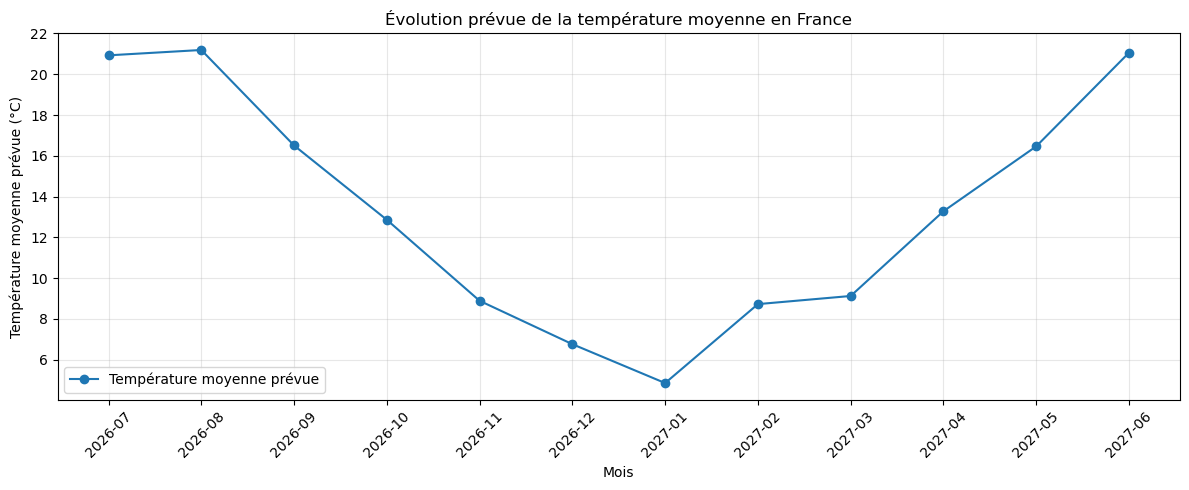

In [241]:
# ==========================
# Visulations des prédictions
# ==========================

import matplotlib.pyplot as plt

# Sécurité : on garde uniquement les mois prévus
df_predictions_departement["MOIS_ANNEE"] = df_predictions_departement["MOIS_ANNEE"].astype(str)

df_france = (
    df_predictions_departement
    .groupby("MOIS_ANNEE", as_index=False)["TEMP_MOYENNE_C"]
    .mean()
    .sort_values("MOIS_ANNEE")
)

plt.figure(figsize=(12, 5))

plt.plot(
    df_france["MOIS_ANNEE"],
    df_france["TEMP_MOYENNE_C"],
    marker="o",
    label="Température moyenne prévue"
)

plt.title("Évolution prévue de la température moyenne en France")
plt.xlabel("Mois")
plt.ylabel("Température moyenne prévue (°C)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()